<a href="https://colab.research.google.com/github/VISHWAJA-028/ML_Multimodality/blob/main/ML_unstructred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# CELL 1: IMPORT LIBRARIES
# ==========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
import zipfile

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# ==========================================
# CELL 2: MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [6]:
# ==========================================
# CELL 3: LOAD ULTRASOUND ZIP FROM DRIVE
# ==========================================

import os

PCOS_DIR = '/content/drive/MyDrive/PCOS'

ZIP_PATH = os.path.join(
    PCOS_DIR,
    'archive (16).zip'
)

if not os.path.exists(ZIP_PATH):

    raise FileNotFoundError(
        f"""
ZIP file not found:

{ZIP_PATH}

Please check the ZIP filename in Google Drive.
"""
    )

print("Ultrasound ZIP found successfully!")
print("ZIP:", ZIP_PATH)

Ultrasound ZIP found successfully!
ZIP: /content/drive/MyDrive/PCOS/archive (16).zip


In [7]:
# ==========================================
# CELL 4: EXTRACT DATASET
# ==========================================

import zipfile
import os

EXTRACT_DIR = '/content/dataset'

# Remove old extracted dataset if necessary
# This prevents old files from mixing with new files.

if os.path.exists(EXTRACT_DIR):

    import shutil

    shutil.rmtree(EXTRACT_DIR)

os.makedirs(
    EXTRACT_DIR,
    exist_ok=True
)

# Extract ZIP
with zipfile.ZipFile(
    ZIP_PATH,
    'r'
) as z:

    z.extractall(
        EXTRACT_DIR
    )

print("Dataset extracted successfully!")
print("Extraction location:", EXTRACT_DIR)

Dataset extracted successfully!
Extraction location: /content/dataset


In [8]:
# ==========================================
# CELL 5: DATASET PATH
# ==========================================

DATA_ROOT = '/content/dataset/archive (7)/PCOS'

if not os.path.exists(DATA_ROOT):

    raise FileNotFoundError(
        f"Dataset folder not found:\n{DATA_ROOT}"
    )

print("DATA_ROOT:")
print(DATA_ROOT)

print("\nContents:")
print(os.listdir(DATA_ROOT))

DATA_ROOT:
/content/dataset/archive (7)/PCOS

Contents:
['infected', 'noninfected']


In [9]:
# ==========================================
# CELL 6: IMAGE SETTINGS
# ==========================================

IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

CLASS_NAMES = [
    'infected',
    'noninfected'
]

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Batch size: 32
Classes: ['infected', 'noninfected']


ORIGINAL DATASET
infected: 6784
noninfected: 5000


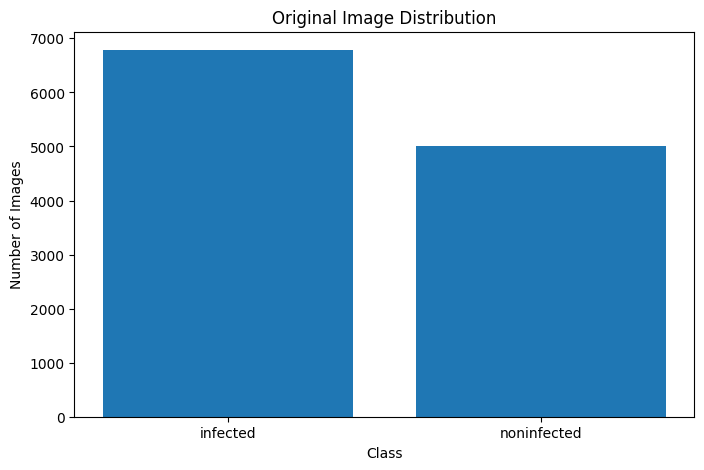

In [10]:
# ==========================================
# CELL 7: CHECK ORIGINAL CLASS BALANCE
# ==========================================

image_extensions = (
    '.jpg',
    '.jpeg',
    '.png',
    '.bmp',
    '.webp'
)

class_counts = {}

for class_name in CLASS_NAMES:

    class_path = os.path.join(
        DATA_ROOT,
        class_name
    )

    if not os.path.exists(class_path):

        raise FileNotFoundError(
            f"Class folder not found: {class_path}"
        )

    count = sum(
        f.lower().endswith(image_extensions)
        for f in os.listdir(class_path)
    )

    class_counts[class_name] = count

print("ORIGINAL DATASET")
print("================")

for class_name, count in class_counts.items():

    print(
        f"{class_name}: {count}"
    )

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Original Image Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

In [11]:
# ==========================================
# CELL 8: COLLECT IMAGE PATHS AND LABELS
# ==========================================

image_paths = []

labels = []

# ------------------------------------------
# infected = 0
# noninfected = 1
# ------------------------------------------

CLASS_TO_INDEX = {
    'infected': 0,
    'noninfected': 1
}

for class_name in CLASS_NAMES:

    class_folder = os.path.join(
        DATA_ROOT,
        class_name
    )

    for filename in os.listdir(class_folder):

        if filename.lower().endswith(
            image_extensions
        ):

            image_paths.append(
                os.path.join(
                    class_folder,
                    filename
                )
            )

            labels.append(
                CLASS_TO_INDEX[class_name]
            )

image_paths = np.array(
    image_paths
)

labels = np.array(
    labels
)

print("Total images:", len(image_paths))

print(
    "Infected:",
    np.sum(labels == 0)
)

print(
    "Noninfected:",
    np.sum(labels == 1)
)

Total images: 11784
Infected: 6784
Noninfected: 5000


In [12]:
# ==========================================
# CELL 9: STRATIFIED TRAIN / VALIDATION / TEST
# ==========================================

# ------------------------------------------
# First split:
# 70% TRAIN
# 30% TEMPORARY
# ------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(

    image_paths,

    labels,

    test_size=0.30,

    random_state=SEED,

    shuffle=True,

    stratify=labels
)

# ------------------------------------------
# Second split:
# TEMPORARY → 50% VALIDATION
#             50% TEST
#
# Therefore:
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
# ------------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(

    temp_paths,

    temp_labels,

    test_size=0.50,

    random_state=SEED,

    shuffle=True,

    stratify=temp_labels
)

# ------------------------------------------
# PRINT DISTRIBUTION
# ------------------------------------------

print("==========================================")
print("STRATIFIED DATA SPLIT")
print("==========================================")

print("\nTRAINING SET")

print("Total:", len(train_paths))

print(
    "Infected:",
    np.sum(train_labels == 0)
)

print(
    "Noninfected:",
    np.sum(train_labels == 1)
)

print("\nVALIDATION SET")

print("Total:", len(val_paths))

print(
    "Infected:",
    np.sum(val_labels == 0)
)

print(
    "Noninfected:",
    np.sum(val_labels == 1)
)

print("\nTEST SET")

print("Total:", len(test_paths))

print(
    "Infected:",
    np.sum(test_labels == 0)
)

print(
    "Noninfected:",
    np.sum(test_labels == 1)
)

STRATIFIED DATA SPLIT

TRAINING SET
Total: 8248
Infected: 4748
Noninfected: 3500

VALIDATION SET
Total: 1768
Infected: 1018
Noninfected: 750

TEST SET
Total: 1768
Infected: 1018
Noninfected: 750


In [13]:
# ==========================================
# CELL 10: IMAGE LOADING FUNCTION
# ==========================================

def load_image(path, label):

    # Read image
    image = tf.io.read_file(path)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Set fixed shape
    image.set_shape(
        [IMG_SIZE[0], IMG_SIZE[1], 3]
    )

    return (
        image,
        tf.cast(label, tf.float32)
    )

In [14]:
# ==========================================
# CELL 11: CREATE TF.DATA DATASETS
# ==========================================

# ------------------------------------------
# TRAIN DATASET
# ------------------------------------------

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_labels
    )
)

train_ds = train_ds.shuffle(
    buffer_size=len(train_paths),
    seed=SEED,
    reshuffle_each_iteration=True
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------
# VALIDATION DATASET
# ------------------------------------------

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_paths,
        val_labels
    )
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.prefetch(
    tf.data.AUTOTUNE
)

# ------------------------------------------
# TEST DATASET
# ------------------------------------------

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_paths,
        test_labels
    )
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(
    BATCH_SIZE
)

test_ds = test_ds.prefetch(
    tf.data.AUTOTUNE
)

print("Train, validation and test datasets created successfully!")

Train, validation and test datasets created successfully!


In [15]:
# ==========================================
# CELL 12: VERIFY VALIDATION CLASSES
# ==========================================

val_labels_check = np.concatenate([

    labels.numpy().ravel()

    for images, labels in val_ds
])

print("==========================================")
print("VALIDATION DATASET CHECK")
print("==========================================")

print(
    "Total images:",
    len(val_labels_check)
)

print(
    "Class 0 (infected):",
    np.sum(val_labels_check == 0)
)

print(
    "Class 1 (noninfected):",
    np.sum(val_labels_check == 1)
)

print(
    "Unique classes:",
    np.unique(val_labels_check)
)

VALIDATION DATASET CHECK
Total images: 1768
Class 0 (infected): 1018
Class 1 (noninfected): 750
Unique classes: [0. 1.]


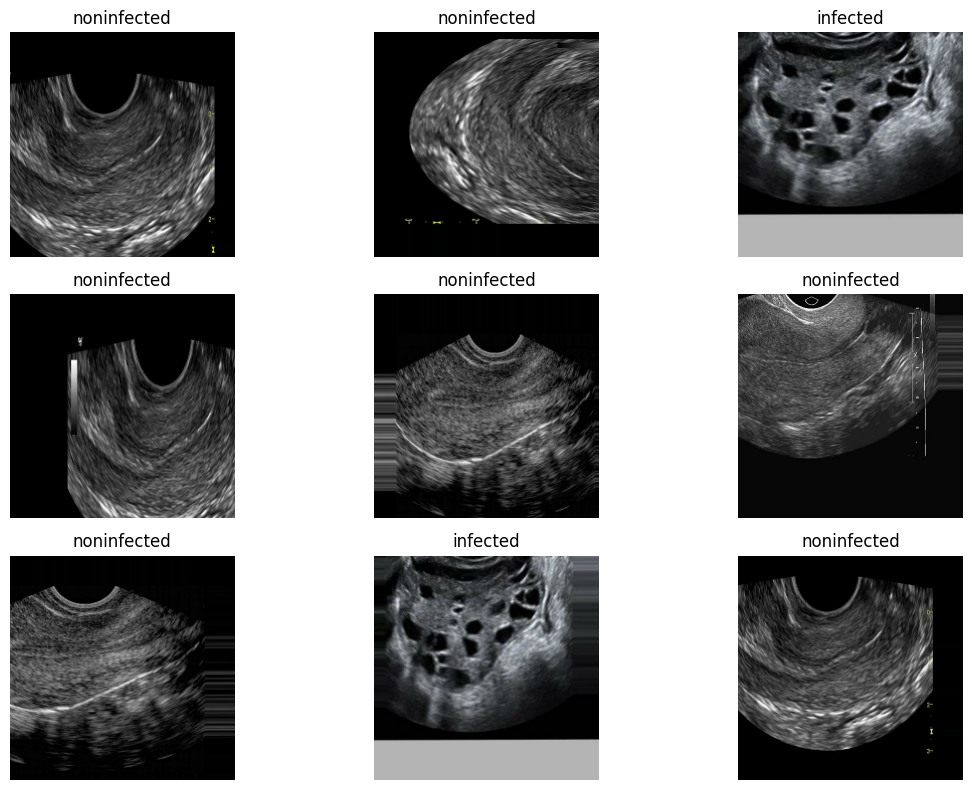

In [17]:
# ==========================================
# CELL 13: SAMPLE IMAGES
# ==========================================

plt.figure(figsize=(12, 8))

for images, labels_batch in train_ds.take(1):

    for i in range(
        min(9, len(images))
    ):

        plt.subplot(
            3,
            3,
            i + 1
        )

        plt.imshow(
            images[i].numpy().astype(
                'uint8'
            )
        )

        class_index = int(
            labels_batch[i].numpy()
        )

        plt.title(
            CLASS_NAMES[class_index]
        )

        plt.axis('off')

plt.tight_layout()

plt.show()

In [18]:
# ==========================================
# CELL 14: DATA AUGMENTATION
# ==========================================

data_augmentation = keras.Sequential([

    layers.RandomRotation(
        0.08
    ),

    layers.RandomZoom(
        0.1
    ),

    layers.RandomContrast(
        0.1
    )

], name="augmentation")

print(
    "Data augmentation created successfully!"
)

Data augmentation created successfully!


In [19]:
# ==========================================
# CELL 15: PRETRAINED MODELS
# ==========================================

from tensorflow.keras.applications import (
    ResNet50,
    MobileNetV2,
    EfficientNetB0
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.efficientnet import (
    preprocess_input as efficientnet_preprocess
)

print("Pretrained models loaded successfully!")

Pretrained models loaded successfully!


In [20]:
# ==========================================
# CELL 16: MODEL ARCHITECTURES
# ==========================================

ARCHITECTURES = {

    'ResNet50': (
        ResNet50,
        resnet_preprocess
    ),

    'MobileNetV2': (
        MobileNetV2,
        mobilenet_preprocess
    ),

    'EfficientNetB0': (
        EfficientNetB0,
        efficientnet_preprocess
    )
}

print("Models to compare:")

for name in ARCHITECTURES:

    print(
        "-",
        name
    )

Models to compare:
- ResNet50
- MobileNetV2
- EfficientNetB0


In [21]:
# ==========================================
# CELL 17: BUILD TRANSFER LEARNING MODEL
# ==========================================

def build_model(
    base_class,
    preprocess_fn
):

    # --------------------------------------
    # Pretrained backbone
    # --------------------------------------

    base = base_class(

        weights='imagenet',

        include_top=False,

        input_shape=IMG_SIZE + (3,)
    )

    # Freeze pretrained layers
    base.trainable = False

    # --------------------------------------
    # Input
    # --------------------------------------

    inputs = keras.Input(
        shape=IMG_SIZE + (3,)
    )

    # --------------------------------------
    # Data augmentation
    # --------------------------------------

    x = data_augmentation(
        inputs,
        training=True
    )

    # --------------------------------------
    # Preprocessing
    # --------------------------------------

    x = preprocess_fn(x)

    # --------------------------------------
    # CNN backbone
    # --------------------------------------

    x = base(
        x,
        training=False
    )

    # --------------------------------------
    # Classification head
    # --------------------------------------

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(
        0.3
    )(x)

    x = layers.Dense(
        64,
        activation='relu'
    )(x)

    x = layers.Dropout(
        0.2
    )(x)

    # --------------------------------------
    # Binary output
    # --------------------------------------

    outputs = layers.Dense(
        1,
        activation='sigmoid'
    )(x)

    # --------------------------------------
    # Create model
    # --------------------------------------

    model = keras.Model(
        inputs,
        outputs
    )

    # --------------------------------------
    # Compile
    # --------------------------------------

    model.compile(

        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),

        loss='binary_crossentropy',

        metrics=[

            'accuracy',

            keras.metrics.AUC(
                name='auc'
            )
        ]
    )

    return model, base

print("Model building function created successfully!")

Model building function created successfully!


In [22]:
# ==========================================
# CELL 18: MODEL COMPARISON
# ==========================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

COMPARISON_EPOCHS = 2

comparison_results = {}

trained_models = {}

# IMPORTANT:
# We are using the STRATIFIED val_ds
# created in Cell 11.
#
# DO NOT write:
# val_ds = holdout_ds
#
# holdout_ds no longer exists in our new flow.

for name, (
    base_class,
    preprocess_fn
) in ARCHITECTURES.items():

    print("\n")
    print("=" * 60)
    print(f"TRAINING: {name}")
    print("=" * 60)

    # --------------------------------------
    # Build model
    # --------------------------------------

    model, base = build_model(
        base_class,
        preprocess_fn
    )

    # --------------------------------------
    # Train
    # --------------------------------------

    history = model.fit(

        train_ds,

        validation_data=val_ds,

        epochs=COMPARISON_EPOCHS,

        verbose=1
    )

    # --------------------------------------
    # Predictions
    # --------------------------------------

    val_probs = model.predict(
        val_ds,
        verbose=0
    ).ravel()

    # --------------------------------------
    # Get validation labels
    # --------------------------------------

    val_labels_actual = np.concatenate([

        labels.numpy().ravel()

        for images, labels in val_ds

    ])

    # --------------------------------------
    # Convert probability to class
    # --------------------------------------

    val_preds = (
        val_probs >= 0.5
    ).astype(int)

    # --------------------------------------
    # Check classes
    # --------------------------------------

    unique_classes = np.unique(
        val_labels_actual
    )

    print(
        "\nValidation classes found:",
        unique_classes
    )

    # --------------------------------------
    # Accuracy
    # --------------------------------------

    accuracy = accuracy_score(

        val_labels_actual,

        val_preds
    )

    # --------------------------------------
    # Precision
    # --------------------------------------

    precision = precision_score(

        val_labels_actual,

        val_preds,

        zero_division=0
    )

    # --------------------------------------
    # Recall
    # --------------------------------------

    recall = recall_score(

        val_labels_actual,

        val_preds,

        zero_division=0
    )

    # --------------------------------------
    # F1
    # --------------------------------------

    f1 = f1_score(

        val_labels_actual,

        val_preds,

        zero_division=0
    )

    # --------------------------------------
    # AUC
    # --------------------------------------

    if len(unique_classes) == 2:

        auc = roc_auc_score(

            val_labels_actual,

            val_probs
        )

    else:

        auc = float('nan')

        print(
            "WARNING: Only one validation class found."
        )

        print(
            "AUC cannot be calculated."
        )

    # --------------------------------------
    # Store results
    # --------------------------------------

    comparison_results[name] = {

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1-Score': f1,

        'AUC': auc
    }

    # --------------------------------------
    # Store model
    # --------------------------------------

    trained_models[name] = (

        model,

        base,

        preprocess_fn
    )

    # --------------------------------------
    # Print results
    # --------------------------------------

    print(
        f"\n{name} Results"
    )

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1-Score : {f1:.4f}"
    )

    print(
        f"AUC      : {auc:.4f}"
    )



TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 62s 188ms/step - accuracy: 0.9310 - auc: 0.9839 - loss: 0.1608 - val_accuracy: 0.9666 - val_auc: 0.9963 - val_loss: 0.0830
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 73s 176ms/step - accuracy: 0.9627 - auc: 0.9933 - loss: 0.1003 - val_accuracy: 0.9796 - val_auc: 0.9973 - val_loss: 0.0612

Validation classes found: [0. 1.]

ResNet50 Results
Accuracy : 0.9796
Precision: 0.9697
Recall   : 0.9827
F1-Score : 0.9762
AUC      : 0.9976


TRAINING: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9291 - auc: 0.9824 - loss: 0.1685 - val_accuracy: 0.9316 - val_auc: 0.9953 - val_loss: 0.1458
Epoch 2/2
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9594 - auc: 0.9930 - loss: 0.1035 - val_accuracy: 0.8778 - val_auc: 0.9911 - val_loss: 0.3749

Validation classes found: [0. 1.]

MobileNetV2 Results
Accuracy :

In [23]:
# ==========================================
# CELL 18: FINAL MODEL COMPARISON
# ==========================================

import pandas as pd
import numpy as np

comparison_df = pd.DataFrame(
    comparison_results
).T

# Sort models by AUC
comparison_df = comparison_df.sort_values(
    by='AUC',
    ascending=False,
    na_position='last'
)

print("==========================================")
print("FINAL MODEL COMPARISON")
print("==========================================")

display(
    comparison_df.round(4)
)

FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,AUC
ResNet50,0.9796,0.9697,0.9827,0.9762,0.9976
MobileNetV2,0.8778,0.7781,0.9960,0.8737,0.9945
EfficientNetB0,0.9497,0.9045,0.9853,0.9432,0.9942


In [24]:
# ==========================================
# CELL 19: SELECT BEST MODEL
# ==========================================

# Select model with highest AUC
best_model_name = comparison_df['AUC'].idxmax()

print("==========================================")
print("BEST MODEL SELECTED")
print("==========================================")

print(
    "Best model:",
    best_model_name
)

print(
    "AUC:",
    comparison_df.loc[
        best_model_name,
        'AUC'
    ]
)

BEST MODEL SELECTED
Best model: ResNet50
AUC: 0.9975743287491814


In [25]:
# ==========================================
# CELL 20: GET BEST MODEL
# ==========================================

best_model, base_model, preprocess_fn = trained_models[
    best_model_name
]

print(
    "Selected model:",
    best_model_name
)

print(
    "Model loaded successfully!"
)

Selected model: ResNet50
Model loaded successfully!


In [26]:
# ==========================================
# CELL 21: FINE-TUNING
# ==========================================

# Unfreeze the pretrained backbone
base_model.trainable = True

# Freeze all earlier layers
for layer in base_model.layers[:-30]:

    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

# Count trainable layers
trainable_count = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable layers:",
    trainable_count
)

print(
    "Fine-tuning configuration completed!"
)

Trainable layers: 21
Fine-tuning configuration completed!


In [27]:
# ==========================================
# CELL 22: RECOMPILE FOR FINE-TUNING
# ==========================================

best_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='binary_crossentropy',

    metrics=[

        'accuracy',

        keras.metrics.Precision(
            name='precision'
        ),

        keras.metrics.Recall(
            name='recall'
        ),

        keras.metrics.AUC(
            name='auc'
        )
    ]
)

print(
    "Model recompiled for fine-tuning!"
)

Model recompiled for fine-tuning!


In [28]:
# ==========================================
# CELL 23: FINE-TUNE BEST MODEL
# ==========================================

FINE_TUNE_EPOCHS = 10

fine_tune_history = best_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=FINE_TUNE_EPOCHS,

    verbose=1
)

print(
    "Fine-tuning completed!"
)

Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 69s 229ms/step - accuracy: 0.9742 - auc: 0.9961 - loss: 0.0736 - precision: 0.9735 - recall: 0.9654 - val_accuracy: 0.9350 - val_auc: 0.9949 - val_loss: 0.1933 - val_precision: 0.8696 - val_recall: 0.9960
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 53s 205ms/step - accuracy: 0.9802 - auc: 0.9978 - loss: 0.0555 - precision: 0.9790 - recall: 0.9743 - val_accuracy: 0.9276 - val_auc: 0.9973 - val_loss: 0.1726 - val_precision: 0.8542 - val_recall: 1.0000
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 56s 218ms/step - accuracy: 0.9875 - auc: 0.9983 - loss: 0.0408 - precision: 0.9874 - recall: 0.9831 - val_accuracy: 0.9174 - val_auc: 0.9772 - val_loss: 0.4049 - val_precision: 0.8371 - val_recall: 1.0000
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 80s 210ms/step - accuracy: 0.9851 - auc: 0.9985 - loss: 0.0424 - precision: 0.9845 - recall: 0.9803 - val_accuracy: 0.9135 - val_auc: 0.9861 - val_loss: 0.3215 - val_precision: 0.8306 - val_recall: 1.0000
Epoch 5/10
258/258 ━

In [30]:
# ==========================================
# CELL 24: FINAL TEST EVALUATION
# ==========================================

test_results = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\n==========================================")
print("FINAL TEST RESULTS")
print("==========================================")

for metric_name, value in zip(
    best_model.metrics_names,
    test_results
):

    print(
        f"{metric_name}: {value:.4f}"
    )

56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 153ms/step - accuracy: 0.8609 - auc: 0.9273 - loss: 0.9884 - precision: 0.7530 - recall: 1.0000

FINAL TEST RESULTS
loss: 0.9884
compile_metrics: 0.8609


In [31]:
# ==========================================
# CELL 25: TEST PREDICTIONS
# ==========================================

# Get predicted probabilities
test_probs = best_model.predict(
    test_ds,
    verbose=1
).ravel()

# Get actual labels
test_labels = np.concatenate([

    labels.numpy().ravel()

    for images, labels in test_ds

])

# Convert probability to class
test_preds = (
    test_probs >= 0.5
).astype(int)

print(
    "Number of test images:",
    len(test_labels)
)

print(
    "Unique test classes:",
    np.unique(test_labels)
)

56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step
Number of test images: 1768
Unique test classes: [0. 1.]


In [32]:
# ==========================================
# CELL 26: FINAL TEST METRICS
# ==========================================

final_accuracy = accuracy_score(
    test_labels,
    test_preds
)

final_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

final_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

final_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

# Calculate AUC only if both classes exist
if len(np.unique(test_labels)) == 2:

    final_auc = roc_auc_score(
        test_labels,
        test_probs
    )

else:

    final_auc = np.nan

print("\n==========================================")
print("FINAL TEST METRICS")
print("==========================================")

print(
    f"Accuracy : {final_accuracy:.4f}"
)

print(
    f"Precision: {final_precision:.4f}"
)

print(
    f"Recall   : {final_recall:.4f}"
)

print(
    f"F1-Score : {final_f1:.4f}"
)

print(
    f"ROC-AUC  : {final_auc:.4f}"
)


FINAL TEST METRICS
Accuracy : 0.8609
Precision: 0.7530
Recall   : 1.0000
F1-Score : 0.8591
ROC-AUC  : 0.9969


Confusion Matrix:
[[772 246]
 [  0 750]]


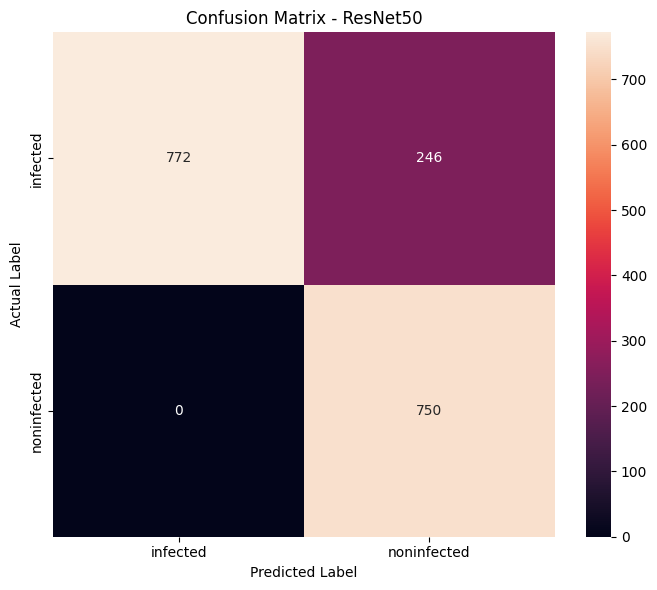

In [33]:
# ==========================================
# CELL 27: CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    test_labels,
    test_preds
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.show()

In [34]:
# ==========================================
# CELL 28: CLASSIFICATION REPORT
# ==========================================

report = classification_report(

    test_labels,

    test_preds,

    target_names=CLASS_NAMES,

    digits=4,

    zero_division=0
)

print(
    "=========================================="
)

print(
    "CLASSIFICATION REPORT"
)

print(
    "=========================================="
)

print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    infected     1.0000    0.7583    0.8626      1018
 noninfected     0.7530    1.0000    0.8591       750

    accuracy                         0.8609      1768
   macro avg     0.8765    0.8792    0.8608      1768
weighted avg     0.8952    0.8609    0.8611      1768



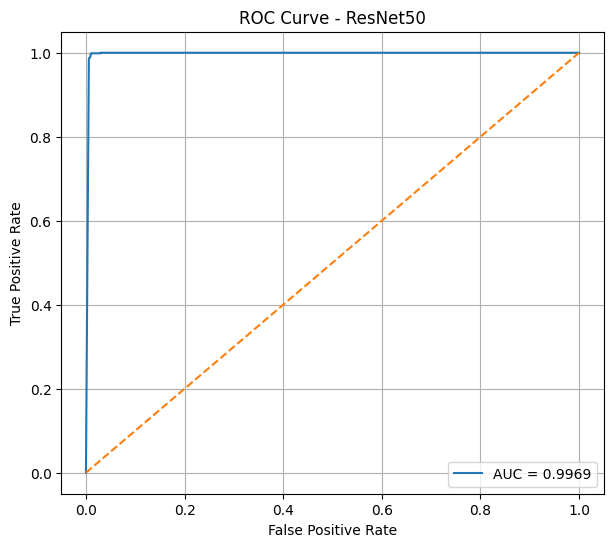

In [35]:
# ==========================================
# CELL 29: ROC CURVE
# ==========================================

if len(np.unique(test_labels)) == 2:

    fpr, tpr, thresholds = roc_curve(
        test_labels,
        test_probs
    )

    roc_auc_value = roc_auc_score(
        test_labels,
        test_probs
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC = {roc_auc_value:.4f}'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--'
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"ROC Curve - {best_model_name}"
    )

    plt.legend()

    plt.grid()

    plt.show()

else:

    print(
        "ROC curve cannot be generated because only one class is present."
    )

In [36]:
# ==========================================
# CELL 30: SAVE FINAL MODEL TO GOOGLE DRIVE
# ==========================================

import os

SAVE_DIR = (
    '/content/drive/MyDrive/PCOS/artifacts'
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    'PCOS_best_image_model.keras'
)

best_model.save(
    MODEL_PATH
)

print("==========================================")
print("FINAL MODEL SAVED")
print("==========================================")

print(
    "Model:",
    best_model_name
)

print(
    "Saved at:",
    MODEL_PATH
)

FINAL MODEL SAVED
Model: ResNet50
Saved at: /content/drive/MyDrive/PCOS/artifacts/PCOS_best_image_model.keras


In [37]:
# ==========================================
# CELL 31: SAVE MODEL INFORMATION
# ==========================================

model_info = {

    "best_model": best_model_name,

    "class_names": CLASS_NAMES,

    "class_mapping": {
        "infected": 0,
        "noninfected": 1
    },

    "image_size": list(IMG_SIZE),

    "threshold": 0.5,

    "accuracy": float(
        final_accuracy
    ),

    "precision": float(
        final_precision
    ),

    "recall": float(
        final_recall
    ),

    "f1_score": float(
        final_f1
    ),

    "roc_auc": float(
        final_auc
    )
}

INFO_PATH = os.path.join(
    SAVE_DIR,
    'PCOS_image_model_info.json'
)

with open(
    INFO_PATH,
    'w'
) as f:

    json.dump(
        model_info,
        f,
        indent=4
    )

print(
    "Model information saved at:"
)

print(
    INFO_PATH
)

Model information saved at:
/content/drive/MyDrive/PCOS/artifacts/PCOS_image_model_info.json


In [38]:
# ==========================================
# CELL 32: SAVE MODEL COMPARISON
# ==========================================

COMPARISON_PATH = os.path.join(
    SAVE_DIR,
    'model_comparison.csv'
)

comparison_df.to_csv(
    COMPARISON_PATH
)

print(
    "Model comparison saved at:"
)

print(
    COMPARISON_PATH
)

Model comparison saved at:
/content/drive/MyDrive/PCOS/artifacts/model_comparison.csv


In [39]:
# ==========================================
# CELL 33: LOAD FINAL MODEL
# ==========================================

from tensorflow import keras

loaded_model = keras.models.load_model(
    MODEL_PATH
)

print(
    "=========================================="
)

print(
    "FINAL MODEL LOADED SUCCESSFULLY"
)

print(
    "=========================================="
)

print(
    "Model:",
    best_model_name
)

FINAL MODEL LOADED SUCCESSFULLY
Model: ResNet50


In [40]:
# ==========================================
# CELL 34: ULTRASOUND PREDICTION FUNCTION
# ==========================================

from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

def predict_ultrasound(
    image_path,
    model=loaded_model
):

    # --------------------------------------
    # Load image
    # --------------------------------------

    image = load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # --------------------------------------
    # Convert image to array
    # --------------------------------------

    image_array = img_to_array(
        image
    )

    # --------------------------------------
    # Add batch dimension
    # --------------------------------------

    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # --------------------------------------
    # Prediction
    # --------------------------------------

    probability = model.predict(
        image_array,
        verbose=0
    )[0][0]

    # --------------------------------------
    # Class
    # --------------------------------------

    if probability >= 0.5:

        prediction = "noninfected"

        confidence = probability

    else:

        prediction = "infected"

        confidence = 1 - probability

    return prediction, confidence

In [41]:
# ==========================================
# CELL 35: TEST SINGLE ULTRASOUND IMAGE
# ==========================================

TEST_IMAGE = test_paths[0]

prediction, confidence = predict_ultrasound(
    TEST_IMAGE
)

print("==========================================")
print("ULTRASOUND PREDICTION")
print("==========================================")

print(
    "Image:",
    TEST_IMAGE
)

print(
    "Prediction:",
    prediction
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

ULTRASOUND PREDICTION
Image: /content/dataset/archive (7)/PCOS/infected/image12011.jpg
Prediction: infected
Confidence: 100.00%
